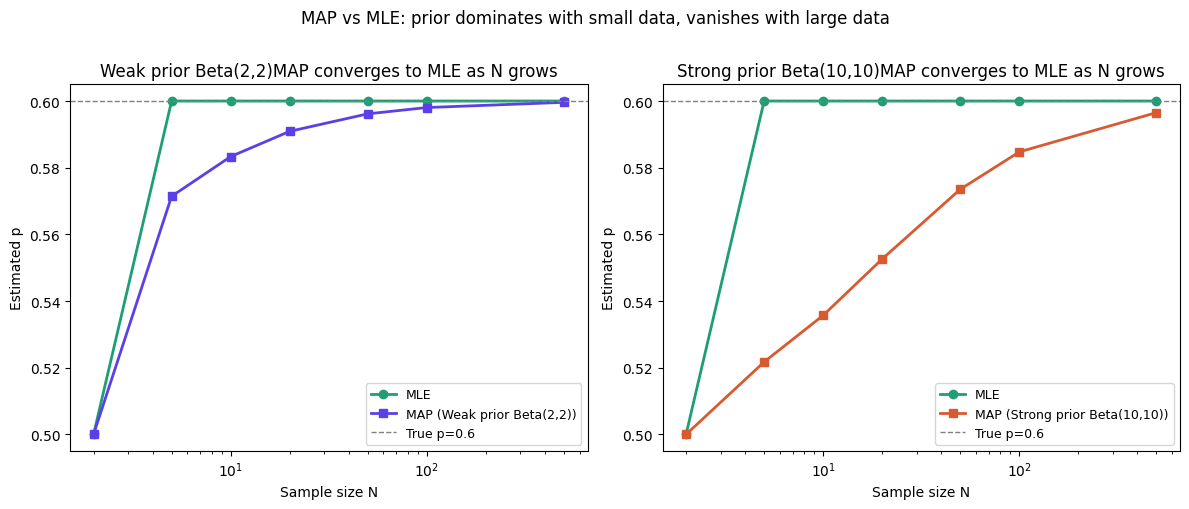

MLE:       μ=3.0125, σ=0.5278
Unbiased:  μ=3.0125, σ=0.5643
Note: MLE σ is biased downward — this is why ddof=1 is default in numpy


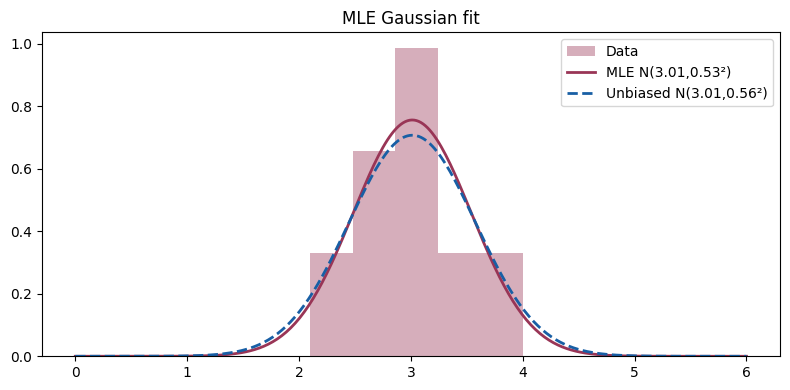

=== L2 regularisation as MAP ===
λ=0 (MLE/no prior): 2.0628
λ=  0.1 (MAP/Gaussian prior σ²=5.00): 2.0545
λ=  1.0 (MAP/Gaussian prior σ²=0.50): 1.9821
λ= 10.0 (MAP/Gaussian prior σ²=0.05): 1.4658
λ=100.0 (MAP/Gaussian prior σ²=0.01): 0.4066
True w: 2.0


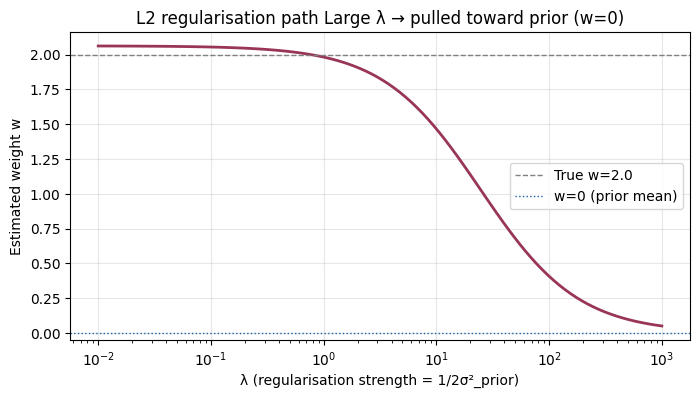

=== L1 vs L2 sparsity ===
   Alpha                               Ridge (L2)                               Lasso (L1)
------------------------------------------------------------------------------------------
    0.01           [ 2.96 -2.02  0.06  0.1  -0.03]           [ 2.95 -2.    0.04  0.08 -0.02]
    0.10           [ 2.95 -2.01  0.06  0.1  -0.03]           [ 2.89 -1.89  0.    0.   -0.  ]
    1.00           [ 2.87 -1.95  0.05  0.09 -0.05]           [ 2.15 -0.82 -0.    0.   -0.  ]
   10.00           [ 2.23 -1.5  -0.02  0.07 -0.14]                          [0. 0. 0. 0. 0.]
    True                     [ 3. -2.  0.  0.  0.]
Note: Lasso (L1) sets irrelevant weights to exactly 0 at larger α
Ridge (L2) shrinks them but never to exactly 0
Save as day12_mle_map.ipynb and push to GitHub.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

np.random.seed(42)

# ── 1. MLE for Bernoulli — coin flip ─────────────────────
def mle_bernoulli(k, N):
    """MLE estimate of Bernoulli p from k successes in N trials."""
    return k / N

def map_bernoulli(k, N, alpha, beta):
    """MAP estimate with Beta(alpha,beta) prior."""
    return (k + alpha - 1) / (N + alpha + beta - 2)

# Compare MLE vs MAP across sample sizes
priors = [(2,2,'Weak prior Beta(2,2)','#5B3FE8'),
          (10,10,'Strong prior Beta(10,10)','#D85A30')]
true_p = 0.6
sample_sizes = [2, 5, 10, 20, 50, 100, 500]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (alpha, beta, label, color) in zip(axes, priors):
    mle_ests, map_ests = [], []
    for N in sample_sizes:
        k = int(true_p * N)
        mle_ests.append(mle_bernoulli(k, N))
        map_ests.append(map_bernoulli(k, N, alpha, beta))
    ax.plot(sample_sizes, mle_ests, 'o-', color='#1D9E75', label='MLE', lw=2)
    ax.plot(sample_sizes, map_ests, 's-', color=color,   label=f'MAP ({label})', lw=2)
    ax.axhline(true_p, color='gray', lw=1, ls='--', label=f'True p={true_p}')
    ax.set_xscale('log'); ax.set_xlabel('Sample size N')
    ax.set_ylabel('Estimated p'); ax.legend(fontsize=9)
    ax.set_title(f'{label}MAP converges to MLE as N grows')
plt.suptitle('MAP vs MLE: prior dominates with small data, vanishes with large data', y=1.01)
plt.tight_layout(); plt.show()

# ── 2. MLE for Gaussian ──────────────────────────────────
data = np.array([2.1, 3.4, 2.8, 3.1, 2.6, 4.0, 2.9, 3.2])

mu_mle    = data.mean()
sigma_mle = data.std(ddof=0)      # MLE uses N not N-1
sigma_unb = data.std(ddof=1)      # unbiased uses N-1

print(f"MLE:       μ={mu_mle:.4f}, σ={sigma_mle:.4f}")
print(f"Unbiased:  μ={mu_mle:.4f}, σ={sigma_unb:.4f}")
print(f"Note: MLE σ is biased downward — this is why ddof=1 is default in numpy")

x = np.linspace(0, 6, 300)
plt.figure(figsize=(8,4))
plt.hist(data, bins=5, density=True, alpha=0.4, color='#993556', label='Data')
plt.plot(x, stats.norm.pdf(x, mu_mle, sigma_mle), color='#993556', lw=2, label=f'MLE N({mu_mle:.2f},{sigma_mle:.2f}²)')
plt.plot(x, stats.norm.pdf(x, mu_mle, sigma_unb), color='#185FA5', lw=2, ls='--', label=f'Unbiased N({mu_mle:.2f},{sigma_unb:.2f}²)')
plt.legend(); plt.title('MLE Gaussian fit'); plt.tight_layout(); plt.show()

# ── 3. L2 regularisation = MAP with Gaussian prior ───────
print("=== L2 regularisation as MAP ===")

# Generate regression data
N = 30
X = np.random.randn(N, 1)
true_w = 2.0
y = true_w * X.flatten() + 0.5*np.random.randn(N)

# MLE (ordinary least squares) = minimise sum of squared residuals
def mle_loss(w): return np.sum((y - w*X.flatten())**2)

# MAP with Gaussian prior (= L2 regularised)
def map_loss(w, lam): return np.sum((y - w*X.flatten())**2) + lam * w**2

lambdas  = [0, 0.1, 1.0, 10.0, 100.0]
w_estimates = {}
for lam in lambdas:
    result = optimize.minimize_scalar(lambda w: map_loss(w, lam))
    w_estimates[lam] = result.x

print("λ=0 (MLE/no prior):", w_estimates[0].round(4))
for lam in lambdas[1:]:
    print(f"λ={lam:5.1f} (MAP/Gaussian prior σ²={1/(2*lam):.2f}):", w_estimates[lam].round(4))
print(f"True w: {true_w}")

plt.figure(figsize=(8,4))
lam_range = np.logspace(-2, 3, 100)
w_path = [optimize.minimize_scalar(lambda w: map_loss(w,l)).x for l in lam_range]
plt.semilogx(lam_range, w_path, color='#993556', lw=2)
plt.axhline(true_w, color='gray', lw=1, ls='--', label=f'True w={true_w}')
plt.axhline(0, color='#185FA5', lw=1, ls=':', label='w=0 (prior mean)')
plt.xlabel('λ (regularisation strength = 1/2σ²_prior)')
plt.ylabel('Estimated weight w')
plt.title('L2 regularisation path Large λ → pulled toward prior (w=0)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# ── 4. L1 vs L2: sparsity demonstration ──────────────────
print("=== L1 vs L2 sparsity ===")
# 5 features, only 2 are truly relevant
N_feat = 30; D = 5
X_feat = np.random.randn(N_feat, D)
true_w_feat = np.array([3.0, -2.0, 0.0, 0.0, 0.0])  # only w0,w1 matter
y_feat = X_feat @ true_w_feat + 0.3*np.random.randn(N_feat)

from sklearn.linear_model import Ridge, Lasso
alphas = [0.01, 0.1, 1.0, 10.0]
print(f"{'Alpha':>8} {'Ridge (L2)':>40} {'Lasso (L1)':>40}")
print("-" * 90)
for a in alphas:
    r = Ridge(alpha=a).fit(X_feat, y_feat).coef_
    l = Lasso(alpha=a, max_iter=10000).fit(X_feat, y_feat).coef_
    print(f"{a:>8.2f}  {str(r.round(2)):>40}  {str(l.round(2)):>40}")
print(f"{'True':>8}  {str(true_w_feat):>40}")
print("Note: Lasso (L1) sets irrelevant weights to exactly 0 at larger α")
print("Ridge (L2) shrinks them but never to exactly 0")
print("Save as day12_mle_map.ipynb and push to GitHub.")